# Fileless Malware Detection Using Explainable Machine Learning
## Memory Forensics-Based Analysis on CIC-MalMem-2022 Dataset

**Author:** Ahmed Mahmoud Mohammed  
**Institution:** Faculty of Computers and Information, Luxor University  
**Thesis:** Automated Triage of Fileless Malware in Windows Environments Using XAI & Memory Forensics

---

### Pipeline Overview
```
Phase 1 → Data Loading & Validation
Phase 2 → Exploratory Data Analysis (EDA)
Phase 3 → Preprocessing & Feature Engineering
Phase 4 → Model Training (XGBoost)
Phase 5 → Rigorous Evaluation (CV + Hold-out)
Phase 6 → Explainability (SHAP + LIME)
Phase 7 → Model Comparison
Phase 8 → Leakage & Robustness Audit
Phase 9 → Artifact Export
```

---
## Phase 0 — Imports & Configuration

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# STANDARD LIBRARY
# ─────────────────────────────────────────────────────────────────────────────
import warnings
import os
import time

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# DATA & MATH
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# MACHINE LEARNING
# ─────────────────────────────────────────────────────────────────────────────
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Preprocessing & Pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel, VarianceThreshold

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    permutation_test_score
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

# Persistence
import joblib

# ─────────────────────────────────────────────────────────────────────────────
# EXPLAINABILITY (XAI)
# ─────────────────────────────────────────────────────────────────────────────
import shap
import lime
import lime.lime_tabular

# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
RANDOM_STATE   = 42          # Reproducibility seed
TEST_SIZE      = 0.20        # 80/20 train-test split
N_FOLDS        = 5           # Stratified k-fold CV
SHAP_SAMPLE    = 500         # Max samples for SHAP (performance)
LIME_FEATURES  = 10          # Top features shown in LIME explanation
DATASET_PATH   = 'MalMem2022.csv'
OUTPUT_DIR     = 'outputs/'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Aesthetic settings for publication-quality figures
plt.rcParams.update({
    'figure.dpi'       : 150,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='muted')

print("[✓] All imports successful.")
print(f"[✓] XGBoost version: {xgb.__version__}")
print(f"[✓] Output directory: {os.path.abspath(OUTPUT_DIR)}")

[✓] All imports successful.
[✓] XGBoost version: 3.2.0
[✓] Output directory: C:\Users\Ahmed El-khatib\Data Set\outputs


---
## Phase 1 — Data Loading & Integrity Validation

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────
print("[*] Loading CIC-MalMem-2022 Dataset...")

df_raw = pd.read_csv(DATASET_PATH)

print(f"[✓] Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

# ─────────────────────────────────────────────────────────────────────────────
# INTEGRITY CHECKS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 55)
print(" DATA INTEGRITY REPORT")
print("─" * 55)

# Class distribution
class_counts = df_raw['Class'].value_counts()
print(f"\n[Class Distribution]")
for cls, cnt in class_counts.items():
    pct = cnt / len(df_raw) * 100
    print(f"  {cls:<10} : {cnt:>6,} samples  ({pct:.1f}%)")

# Missing values
missing_total = df_raw.isnull().sum().sum()
print(f"\n[Missing Values]  : {missing_total}")

# Duplicate rows
dup_count = df_raw.duplicated().sum()
print(f"[Duplicate Rows]  : {dup_count}")

# Data types
non_numeric = df_raw.select_dtypes(exclude='number').columns.tolist()
print(f"[Non-numeric Cols]: {non_numeric}")

print("\n[Sample Preview]")
display(df_raw.head(3))

[*] Loading CIC-MalMem-2022 Dataset...
[✓] Loaded: 58,596 rows × 58 columns

───────────────────────────────────────────────────────
 DATA INTEGRITY REPORT
───────────────────────────────────────────────────────

[Class Distribution]
  Benign     : 29,298 samples  (50.0%)
  Malware    : 29,298 samples  (50.0%)

[Missing Values]  : 0
[Duplicate Rows]  : 534
[Non-numeric Cols]: ['Class', 'Category', 'Filename']

[Sample Preview]


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
0,45,17,10.555556,0,202.844444,1694,38.50000,9129,212.302326,0,...,24,116,0,121,87,0,8,Benign,Benign,Benign
1,47,19,11.531915,0,242.234043,2074,44.12766,11385,242.234043,0,...,24,118,0,122,87,0,8,Benign,Benign,Benign
2,40,14,14.725000,0,288.225000,1932,48.30000,11529,288.225000,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign


---
## Phase 2 — Exploratory Data Analysis (EDA)

[*] Generating EDA visualizations...


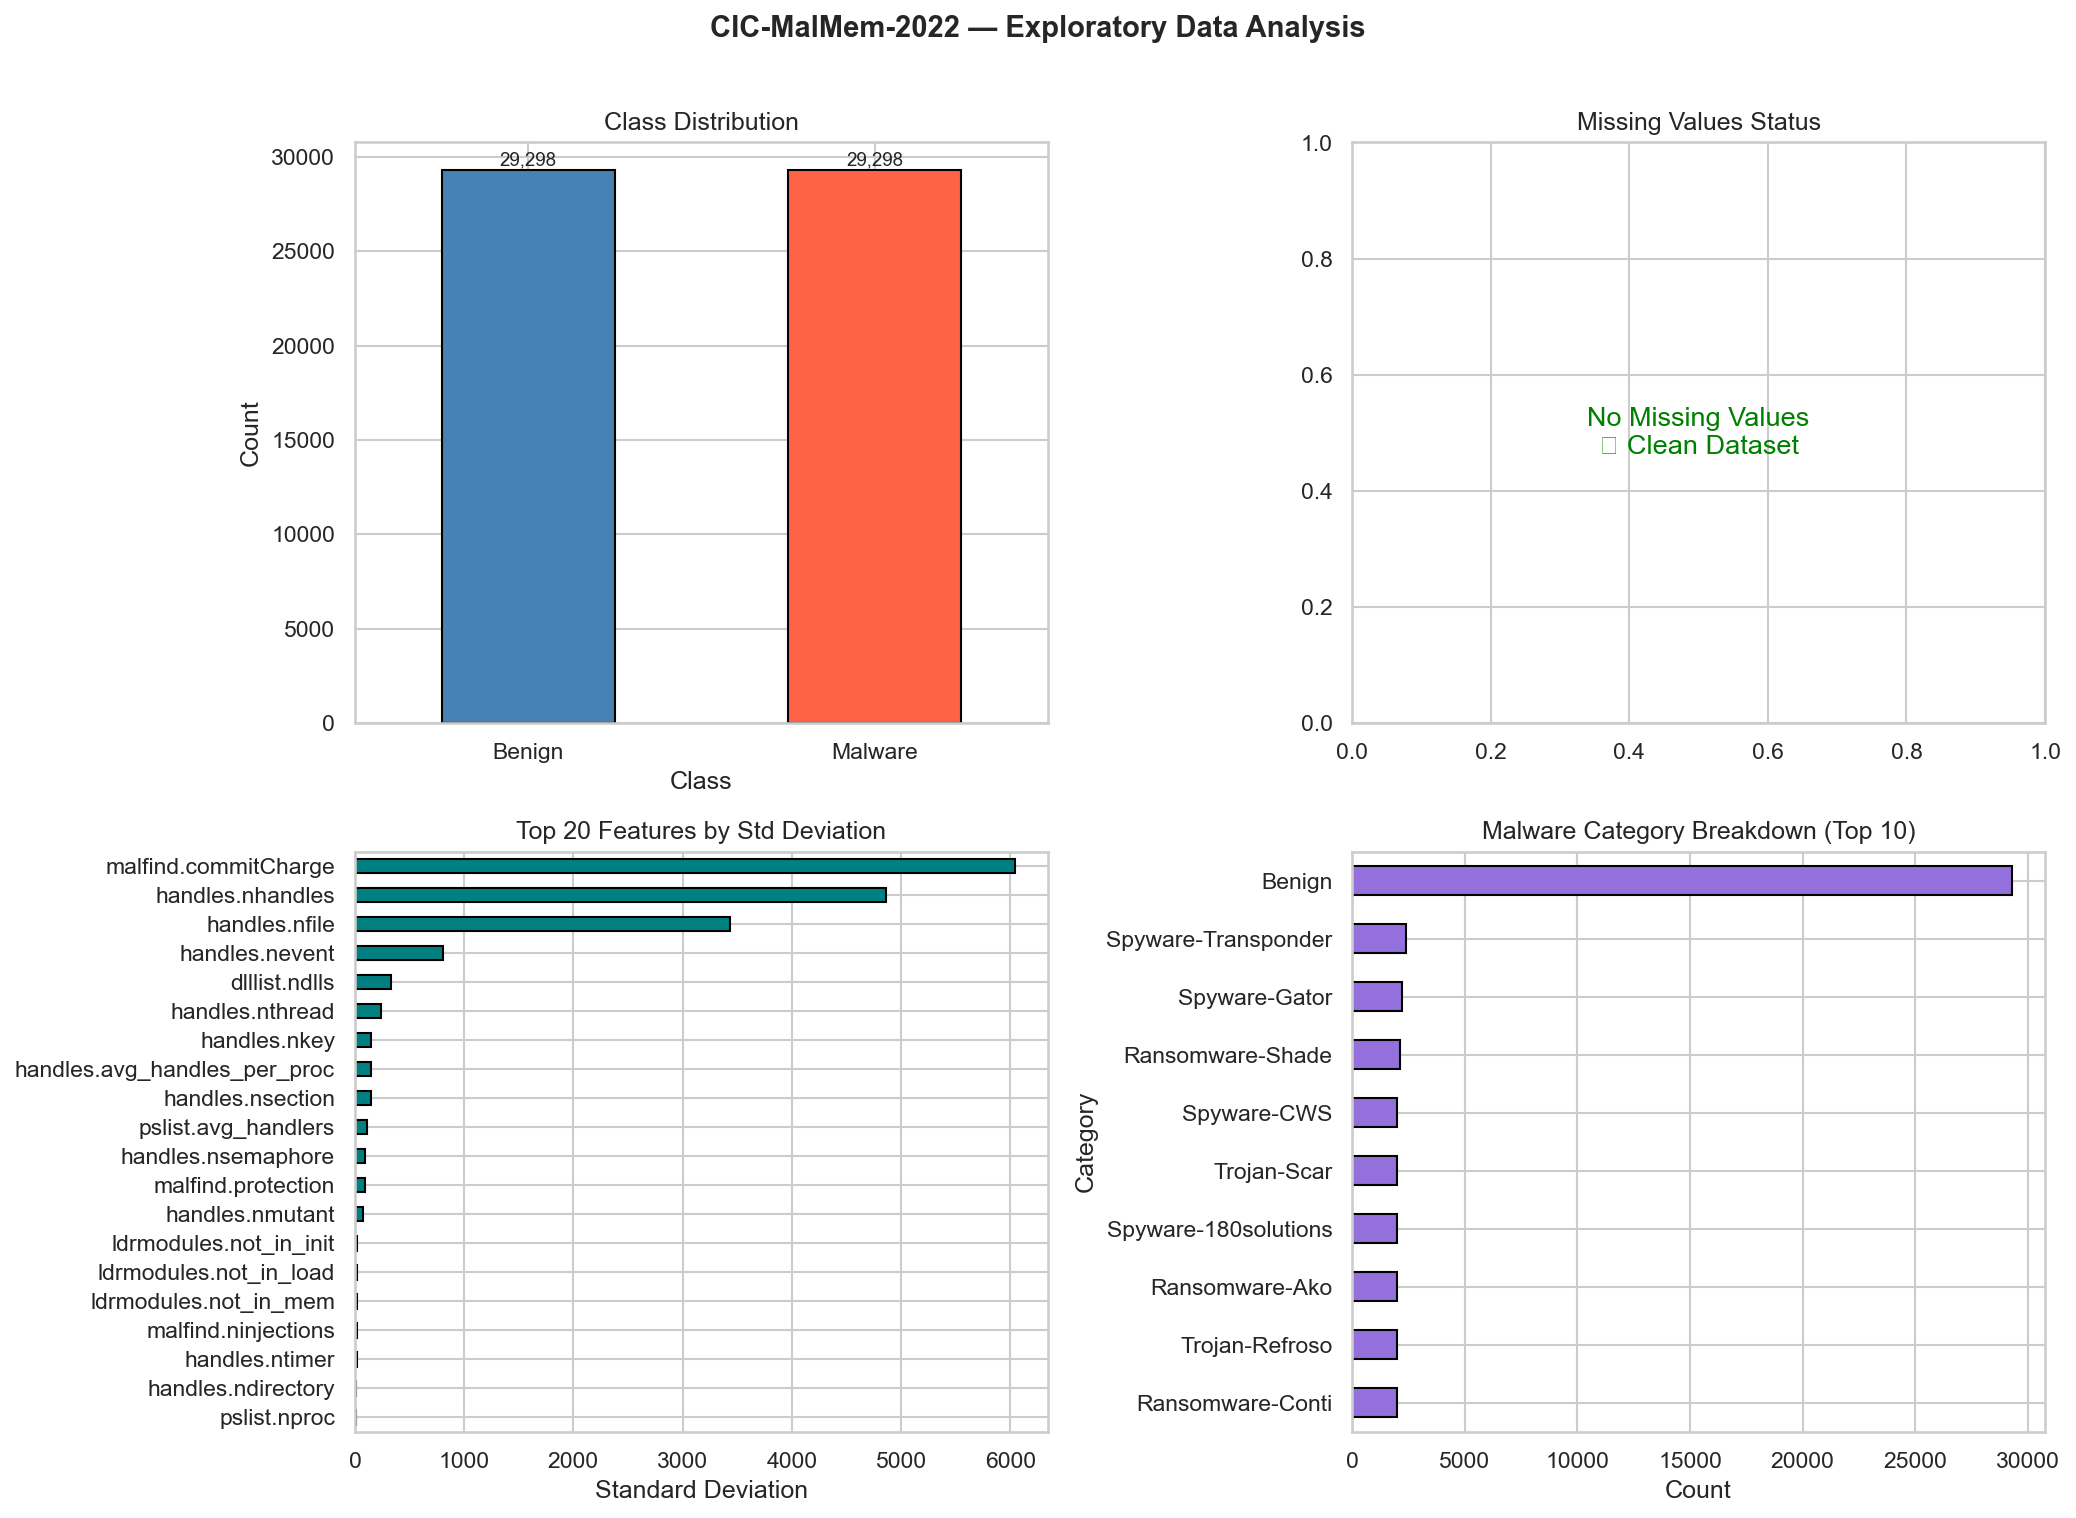

[✓] EDA dashboard saved.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# DESCRIPTIVE STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
print("[*] Generating EDA visualizations...")

numeric_df = df_raw.select_dtypes(include='number')

# Create a 2×2 EDA dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CIC-MalMem-2022 — Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Class Distribution
ax1 = axes[0, 0]
class_counts.plot(kind='bar', ax=ax1, color=['steelblue', 'tomato'], edgecolor='black')
ax1.set_title('Class Distribution')
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)
for bar, val in zip(ax1.patches, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

# ── Plot 2: Missing values heatmap (top-20 features with most NaN)
ax2 = axes[0, 1]
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False).head(20)
if missing_pct.sum() > 0:
    missing_pct.plot(kind='bar', ax=ax2, color='salmon', edgecolor='black')
    ax2.set_title('Missing Values (Top 20 Features)')
    ax2.set_ylabel('Missing %')
else:
    ax2.text(0.5, 0.5, 'No Missing Values\n✓ Clean Dataset',
             ha='center', va='center', fontsize=13, color='green',
             transform=ax2.transAxes)
    ax2.set_title('Missing Values Status')

# ── Plot 3: Feature value range (std deviation across features)
ax3 = axes[1, 0]
std_vals = numeric_df.std().sort_values(ascending=False).head(20)
std_vals.plot(kind='barh', ax=ax3, color='teal', edgecolor='black')
ax3.set_title('Top 20 Features by Std Deviation')
ax3.set_xlabel('Standard Deviation')
ax3.invert_yaxis()

# ── Plot 4: Category breakdown (malware families)
ax4 = axes[1, 1]
if 'Category' in df_raw.columns:
    cat_counts = df_raw['Category'].value_counts().head(10)
    cat_counts.plot(kind='barh', ax=ax4, color='mediumpurple', edgecolor='black')
    ax4.set_title('Malware Category Breakdown (Top 10)')
    ax4.set_xlabel('Count')
    ax4.invert_yaxis()
else:
    ax4.set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}eda_dashboard.png', bbox_inches='tight')
plt.show()
print(f"[✓] EDA dashboard saved.")

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE CORRELATION ANALYSIS (top features vs target)
# ─────────────────────────────────────────────────────────────────────────────

# Binary-encode target for correlation analysis
df_corr = df_raw.copy()
df_corr['Class_bin'] = df_corr['Class'].map({'Benign': 0, 'Malware': 1})

correlations = (
    df_corr
    .select_dtypes(include='number')
    .corr()['Class_bin']
    .drop('Class_bin')
    .abs()
    .sort_values(ascending=False)
)

print("[*] Top 20 Features Correlated with Target (|r|):")
print(correlations.head(20).to_string())

# Flag features with suspicious perfect/near-perfect correlation
leakage_suspects = correlations[correlations > 0.95].index.tolist()
if leakage_suspects:
    print(f"\n[⚠️  WARNING] Potential data leakage — features with |r| > 0.95:")
    for f in leakage_suspects:
        print(f"  → {f}  (r = {correlations[f]:.4f})")
else:
    print("\n[✓] No obvious leakage features detected (all |r| < 0.95).")

[*] Top 20 Features Correlated with Target (|r|):
dlllist.avg_dlls_per_proc          0.908555
handles.nevent                     0.876770
handles.nthread                    0.872531
handles.nmutant                    0.855148
dlllist.ndlls                      0.823933
handles.nsection                   0.820967
pslist.avg_threads                 0.790666
ldrmodules.not_in_load             0.787472
ldrmodules.not_in_mem              0.787413
handles.ntimer                     0.783137
handles.nsemaphore                 0.769097
svcscan.process_services           0.763656
ldrmodules.not_in_init             0.716578
svcscan.shared_process_services    0.710979
handles.nkey                       0.698239
svcscan.nactive                    0.653268
svcscan.nservices                  0.631078
pslist.nppid                       0.429412
handles.ndesktop                   0.392919
handles.nhandles                   0.382270

[✓] No obvious leakage features detected (all |r| < 0.95).


---
## Phase 3 — Preprocessing & Feature Engineering

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Clean & Deduplicate
# ─────────────────────────────────────────────────────────────────────────────
print("[*] Preprocessing pipeline...")

df = df_raw.copy()
df = df.dropna().drop_duplicates().reset_index(drop=True)

print(f"[✓] After cleaning: {df.shape[0]:,} rows")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Encode Target
#   Benign  → 0
#   Malware → 1
# ─────────────────────────────────────────────────────────────────────────────
df['Class_bin'] = df['Class'].map({'Benign': 0, 'Malware': 1})

# Validate encoding
assert df['Class_bin'].isnull().sum() == 0, "Encoding failed — unexpected class labels present!"
print(f"[✓] Target encoded: Benign=0 ({(df.Class_bin==0).sum():,})  |  Malware=1 ({(df.Class_bin==1).sum():,})")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Define Feature Matrix
#   Drop metadata columns and the original string target
# ─────────────────────────────────────────────────────────────────────────────
META_COLS = ['Category', 'Class', 'Filename', 'Class_bin']

feature_cols = [
    col for col in df.columns
    if col not in META_COLS
    and pd.api.types.is_numeric_dtype(df[col])
]

X = df[feature_cols].values.astype(np.float32)   # float32 → faster XGBoost training
y = df['Class_bin'].values

print(f"[✓] Feature matrix shape: {X.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Remove Zero-Variance Features
#   Features with zero variance carry no discriminative power
# ─────────────────────────────────────────────────────────────────────────────
vt = VarianceThreshold(threshold=0.0)
X_vt = vt.fit_transform(X)

removed = X.shape[1] - X_vt.shape[1]
feature_cols = [f for f, keep in zip(feature_cols, vt.get_support()) if keep]
X = X_vt

print(f"[✓] Removed {removed} zero-variance features. Remaining: {len(feature_cols)}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Train / Test Split
#   stratify=y  → ensures balanced class proportions in both sets
#   NOTE: Scaler is fit ONLY on training data to prevent data leakage
# ─────────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"[✓] Train set : {X_train.shape[0]:,} samples")
print(f"[✓] Test set  : {X_test.shape[0]:,} samples")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: Feature Scaling
#   StandardScaler: fit on X_train ONLY, then transform both sets
#   This is critical — fitting on full data would leak test statistics
# ─────────────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # ← fit here only
X_test_scaled  = scaler.transform(X_test)         # ← just transform, no re-fitting

print("[✓] Feature scaling applied (StandardScaler — zero mean, unit variance).")
print("[✓] Preprocessing complete.")

[*] Preprocessing pipeline...
[✓] After cleaning: 58,062 rows
[✓] Target encoded: Benign=0 (29,231)  |  Malware=1 (28,831)
[✓] Feature matrix shape: (58062, 55)
[✓] Removed 3 zero-variance features. Remaining: 52
[✓] Train set : 46,449 samples
[✓] Test set  : 11,613 samples
[✓] Feature scaling applied (StandardScaler — zero mean, unit variance).
[✓] Preprocessing complete.


---
## Phase 4 — Model Training (XGBoost)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# XGBOOST HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
# Parameter justification:
#   n_estimators    = 300   → enough trees for convergence on this dataset size
#   max_depth       = 5     → moderately complex trees; avoids memorising noise
#   learning_rate   = 0.05  → conservative step size; generalization improves
#   subsample       = 0.8   → row subsampling; reduces overfitting variance
#   colsample_bytree= 0.8   → column subsampling per tree (like Random Forest)
#   reg_lambda      = 1.0   → L2 regularization on leaf weights
#   reg_alpha       = 0.1   → L1 regularization; drives sparse feature usage
#   min_child_weight= 5     → min samples per leaf; prevents tiny, noisy splits
#   gamma           = 0.1   → minimum loss reduction to allow a split
# ─────────────────────────────────────────────────────────────────────────────

xgb_params = dict(
    n_estimators     = 300,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_lambda       = 1.0,
    reg_alpha        = 0.1,
    min_child_weight = 5,
    gamma            = 0.1,
    eval_metric      = 'logloss',
    random_state     = RANDOM_STATE,
    n_jobs           = -1
)

print("[*] Training XGBoost Classifier...")
t0 = time.time()

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50    # print loss every 50 rounds
)

elapsed = time.time() - t0
print(f"\n[✓] Training complete in {elapsed:.1f}s")

[*] Training XGBoost Classifier...
[0]	validation_0-logloss:0.64454
[50]	validation_0-logloss:0.04035
[100]	validation_0-logloss:0.00388
[150]	validation_0-logloss:0.00072
[200]	validation_0-logloss:0.00037
[250]	validation_0-logloss:0.00032
[299]	validation_0-logloss:0.00029

[✓] Training complete in 1.7s


---
## Phase 5 — Rigorous Evaluation

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 5A — HOLD-OUT TEST SET EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

y_pred  = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Compute all metrics
metrics = {
    'Accuracy'          : accuracy_score(y_test, y_pred),
    'Precision'         : precision_score(y_test, y_pred),
    'Recall (TPR)'      : recall_score(y_test, y_pred),
    'F1-Score'          : f1_score(y_test, y_pred),
    'ROC-AUC'           : roc_auc_score(y_test, y_proba),
    'Avg Precision (PR)': average_precision_score(y_test, y_proba),
    'MCC'               : matthews_corrcoef(y_test, y_pred),
}

print("=" * 55)
print("  MODEL EVALUATION — HOLD-OUT TEST SET")
print("=" * 55)
for metric, value in metrics.items():
    bar = '█' * int(value * 20)
    print(f"  {metric:<25}: {value:.4f}  {bar}")
print("=" * 55)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malware']))

  MODEL EVALUATION — HOLD-OUT TEST SET
  Accuracy                 : 1.0000  ████████████████████
  Precision                : 1.0000  ████████████████████
  Recall (TPR)             : 1.0000  ████████████████████
  F1-Score                 : 1.0000  ████████████████████
  ROC-AUC                  : 1.0000  ███████████████████
  Avg Precision (PR)       : 1.0000  ████████████████████
  MCC                      : 1.0000  ████████████████████

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5847
     Malware       1.00      1.00      1.00      5766

    accuracy                           1.00     11613
   macro avg       1.00      1.00      1.00     11613
weighted avg       1.00      1.00      1.00     11613



In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 5B — STRATIFIED K-FOLD CROSS VALIDATION
#   Measures stability across different data splits
#   A good model should have low std across folds
# ─────────────────────────────────────────────────────────────────────────────

print(f"[*] Running {N_FOLDS}-Fold Stratified Cross-Validation...")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# We run CV on the training data only (not touching test set)
cv_results = cross_validate(
    xgb.XGBClassifier(**xgb_params),
    X_train_scaled, y_train,
    cv=skf,
    scoring=['accuracy', 'f1', 'roc_auc', 'precision', 'recall'],
    n_jobs=-1
)

print("\n" + "─" * 55)
print(f"  {N_FOLDS}-FOLD CROSS-VALIDATION RESULTS (on Training Set)")
print("─" * 55)
for scoring_key in ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']:
    vals = cv_results[f'test_{scoring_key}']
    print(f"  {scoring_key.capitalize():<15}: {vals.mean():.4f} ± {vals.std():.4f}")
print("─" * 55)
print("\n[NOTE] Low std (< 0.005) across folds indicates stable generalization.")

[*] Running 5-Fold Stratified Cross-Validation...

───────────────────────────────────────────────────────
  5-FOLD CROSS-VALIDATION RESULTS (on Training Set)
───────────────────────────────────────────────────────
  Accuracy       : 0.9997 ± 0.0003
  F1             : 0.9997 ± 0.0003
  Roc_auc        : 1.0000 ± 0.0000
  Precision      : 0.9997 ± 0.0004
  Recall         : 0.9997 ± 0.0005
───────────────────────────────────────────────────────

[NOTE] Low std (< 0.005) across folds indicates stable generalization.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 5C — OVERFITTING GAP ANALYSIS
#   Train Acc vs Test Acc: a large gap signals overfitting
# ─────────────────────────────────────────────────────────────────────────────

train_acc = accuracy_score(y_train, xgb_model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  y_pred)
gap       = train_acc - test_acc

print("[OVERFITTING GAP ANALYSIS]")
print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Test Accuracy  : {test_acc:.4f}")
print(f"  Gap            : {gap:.4f}")
print()

if gap < 0.005:
    print("[✓] PASS — No significant overfitting detected (gap < 0.5%).")
elif gap < 0.02:
    print("[~] ACCEPTABLE — Slight overfitting, within normal range (0.5–2%).")
else:
    print("[⚠️ WARNING] — Possible overfitting. Consider stronger regularization.")

[OVERFITTING GAP ANALYSIS]
  Train Accuracy : 1.0000
  Test Accuracy  : 1.0000
  Gap            : -0.0000

[✓] PASS — No significant overfitting detected (gap < 0.5%).


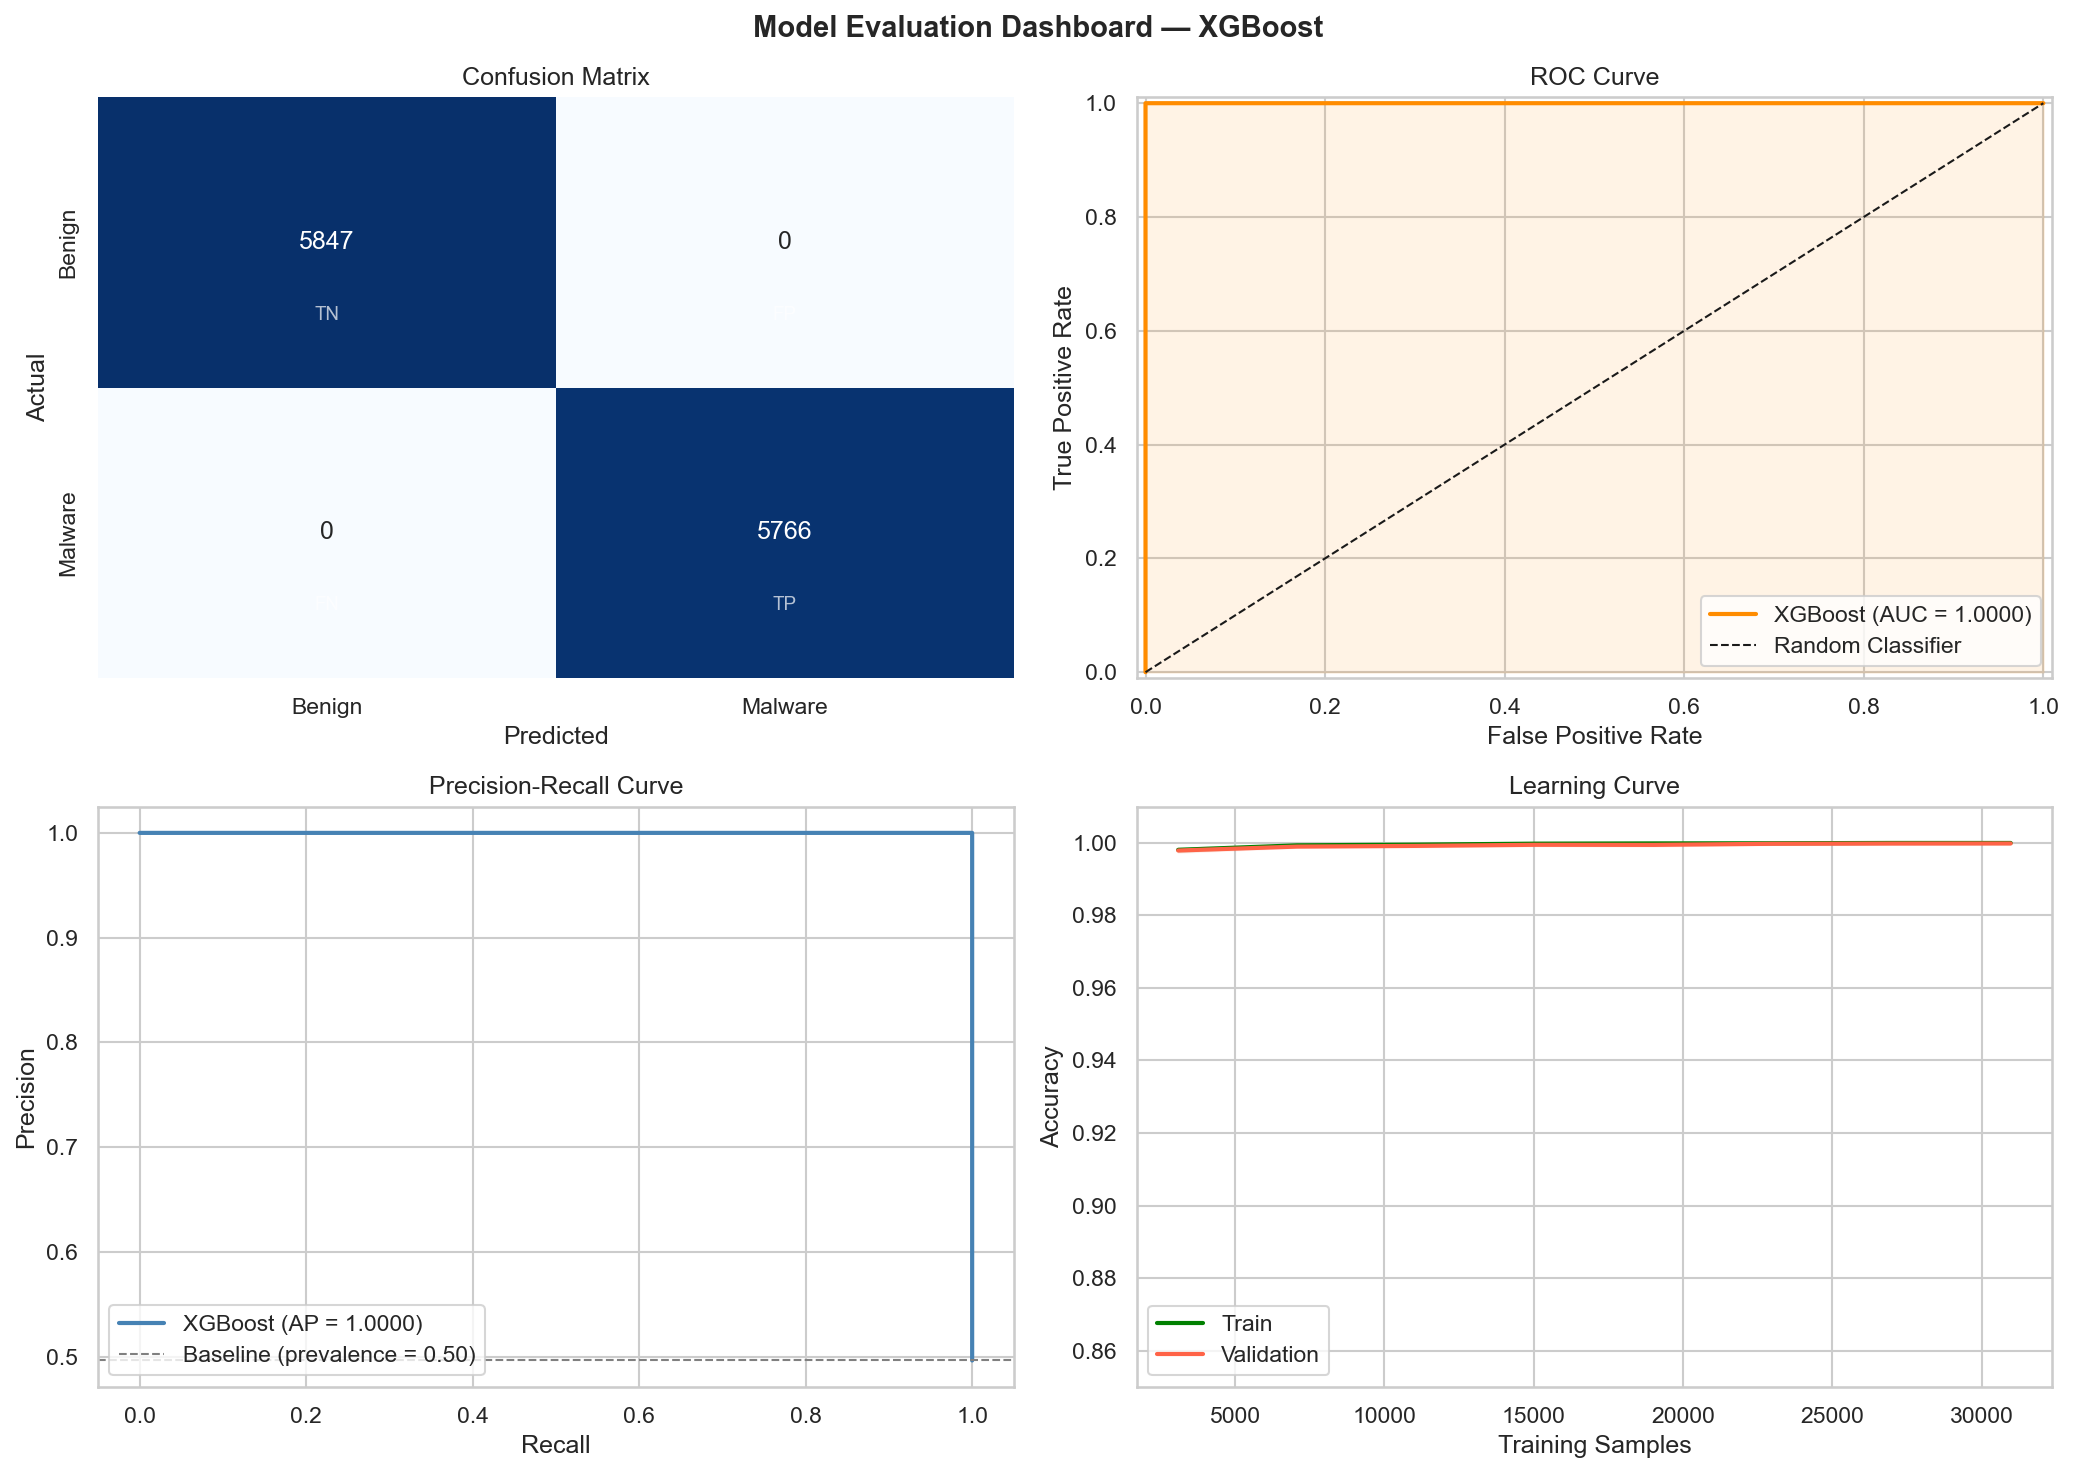

[✓] Evaluation dashboard saved.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 5D — DIAGNOSTIC VISUALIZATIONS (4 plots)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Evaluation Dashboard — XGBoost', fontsize=14, fontweight='bold')

# ── Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benign', 'Malware'],
    yticklabels=['Benign', 'Malware'],
    ax=axes[0, 0], cbar=False
)
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# Annotate TN/FP/FN/TP labels
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0, 0].text(j + 0.5, i + 0.75, labels[i][j],
                        ha='center', va='center', fontsize=9,
                        color='white', alpha=0.7)

# ── Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)

axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2,
                label=f'XGBoost (AUC = {roc_auc_val:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0, 1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')
axes[0, 1].set_xlim([-0.01, 1.01])
axes[0, 1].set_ylim([-0.01, 1.01])

# ── Plot 3: Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_proba)
pr_auc_val = average_precision_score(y_test, y_proba)
baseline_pr = y_test.sum() / len(y_test)

axes[1, 0].plot(recall_arr, precision_arr, color='steelblue', lw=2,
                label=f'XGBoost (AP = {pr_auc_val:.4f})')
axes[1, 0].axhline(y=baseline_pr, color='gray', linestyle='--', lw=1,
                   label=f'Baseline (prevalence = {baseline_pr:.2f})')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc='lower left')

# ── Plot 4: Learning Curve (train vs validation accuracy)
train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBClassifier(**xgb_params),
    X_train_scaled, y_train,
    cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

axes[1, 1].plot(train_sizes, train_scores.mean(axis=1), label='Train', color='green', lw=2)
axes[1, 1].fill_between(train_sizes,
                         train_scores.mean(axis=1) - train_scores.std(axis=1),
                         train_scores.mean(axis=1) + train_scores.std(axis=1),
                         alpha=0.1, color='green')
axes[1, 1].plot(train_sizes, val_scores.mean(axis=1), label='Validation', color='tomato', lw=2)
axes[1, 1].fill_between(train_sizes,
                         val_scores.mean(axis=1) - val_scores.std(axis=1),
                         val_scores.mean(axis=1) + val_scores.std(axis=1),
                         alpha=0.1, color='tomato')
axes[1, 1].set_xlabel('Training Samples')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Learning Curve')
axes[1, 1].legend()
axes[1, 1].set_ylim([0.85, 1.01])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evaluation_dashboard.png', bbox_inches='tight')
plt.show()
print("[✓] Evaluation dashboard saved.")

---
## Phase 6 — Explainability (XAI)

[*] Computing SHAP values (this may take 1–2 minutes)...
[✓] SHAP values computed.


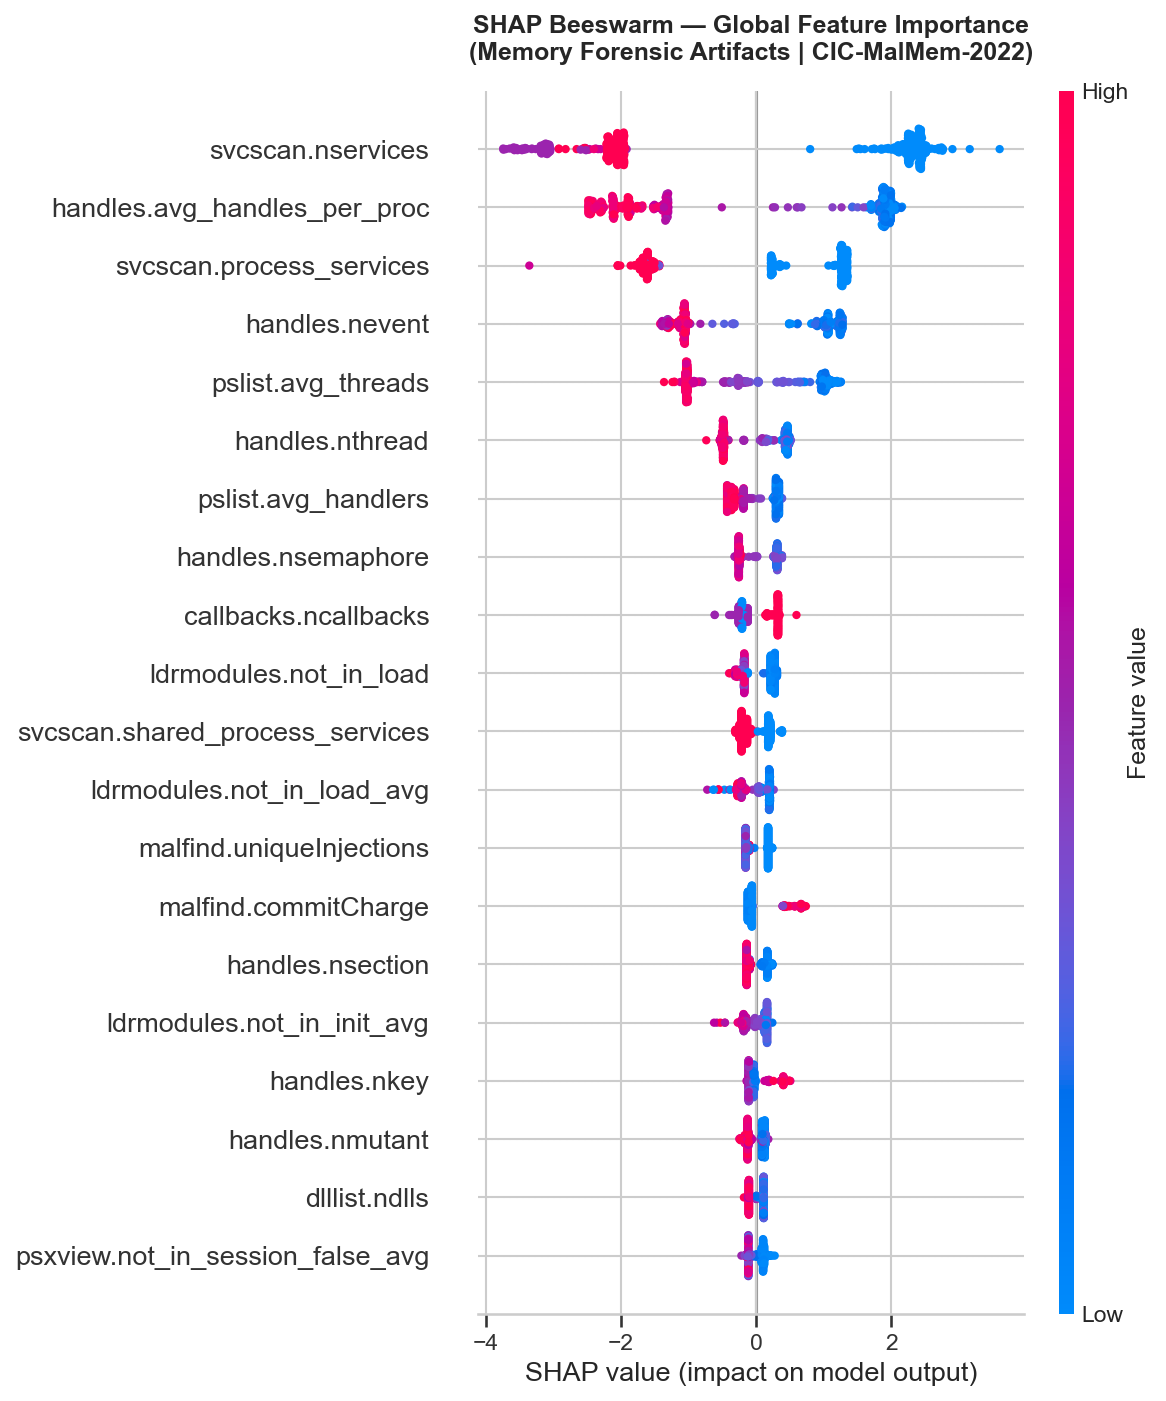

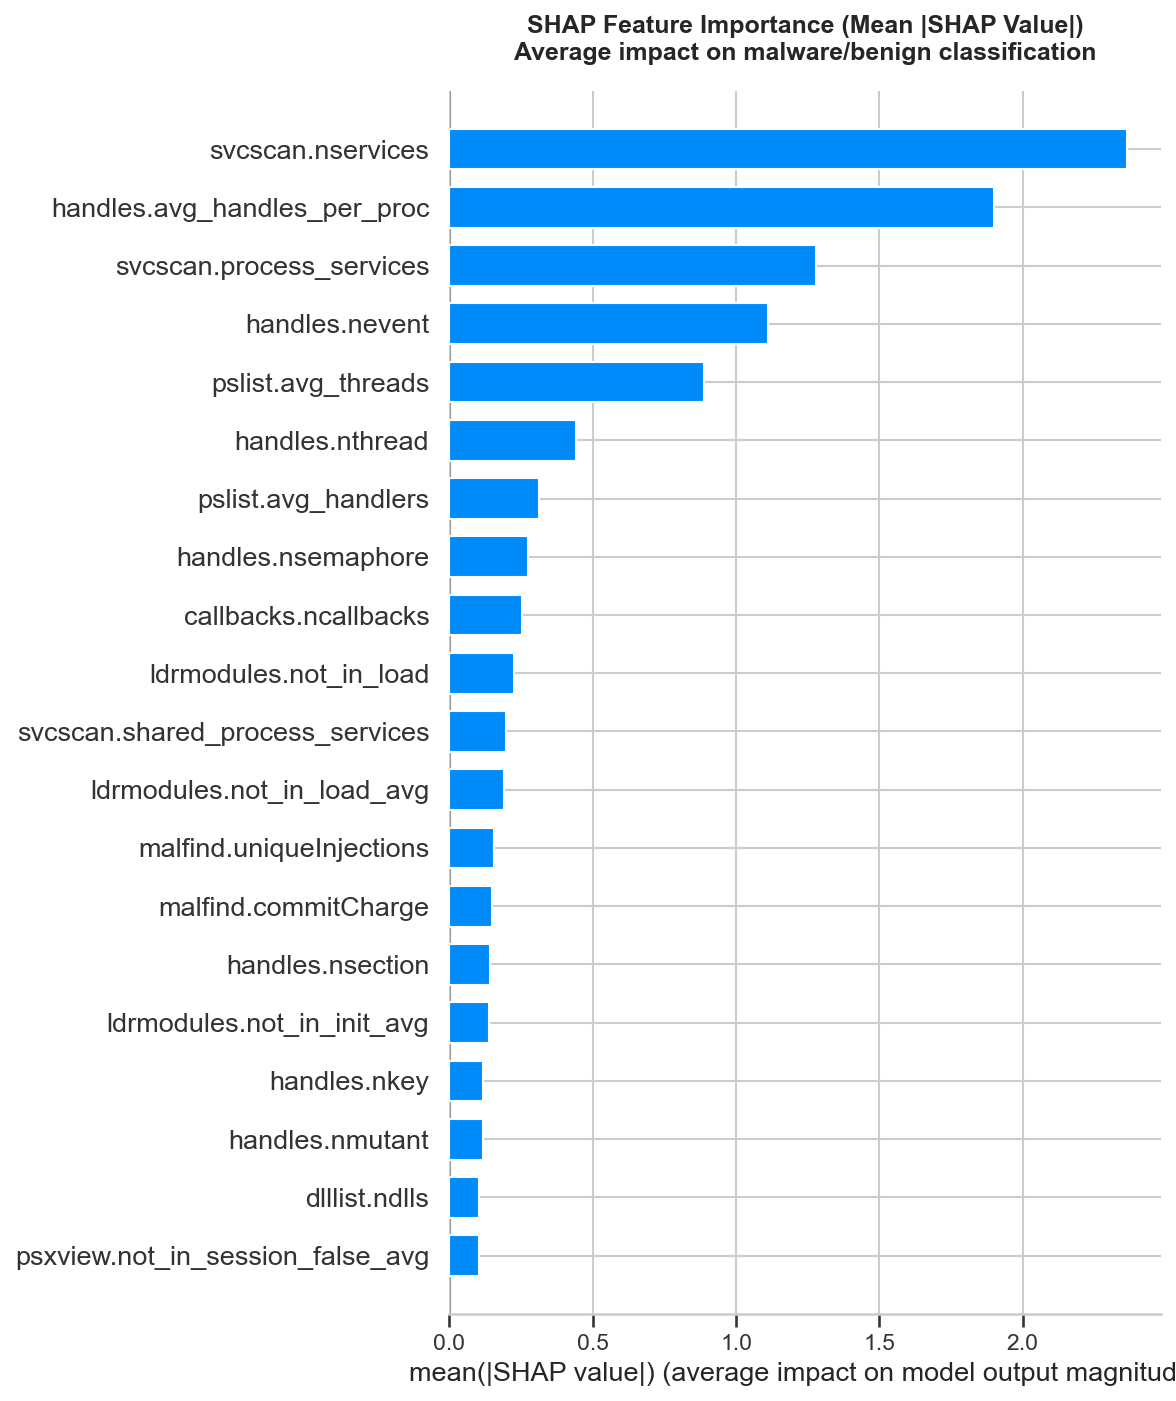

[✓] SHAP plots saved.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 6A — SHAP: GLOBAL EXPLAINABILITY
#
# SHAP (SHapley Additive exPlanations) attributes each feature's contribution
# to the model output. Positive SHAP value → pushes toward Malware prediction.
# ─────────────────────────────────────────────────────────────────────────────

print("[*] Computing SHAP values (this may take 1–2 minutes)...")

# Sample a representative subset for efficiency
shap_idx    = np.random.choice(len(X_test_scaled), size=SHAP_SAMPLE, replace=False)
X_shap      = X_test_scaled[shap_idx]
X_shap_df   = pd.DataFrame(X_shap, columns=feature_cols)

shap_explainer = shap.Explainer(xgb_model, X_shap_df)
shap_values    = shap_explainer(X_shap_df)

print("[✓] SHAP values computed.")

# ── Figure 1: SHAP Beeswarm (Global Summary)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_shap_df,
    feature_names=feature_cols,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title(
    "SHAP Beeswarm — Global Feature Importance\n"
    "(Memory Forensic Artifacts | CIC-MalMem-2022)",
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}shap_beeswarm.png', bbox_inches='tight')
plt.show()

# ── Figure 2: SHAP Mean Absolute Bar Chart
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_shap_df,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title(
    "SHAP Feature Importance (Mean |SHAP Value|)\n"
    "Average impact on malware/benign classification",
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}shap_bar.png', bbox_inches='tight')
plt.show()

print("[✓] SHAP plots saved.")

[*] Setting up LIME explainer...


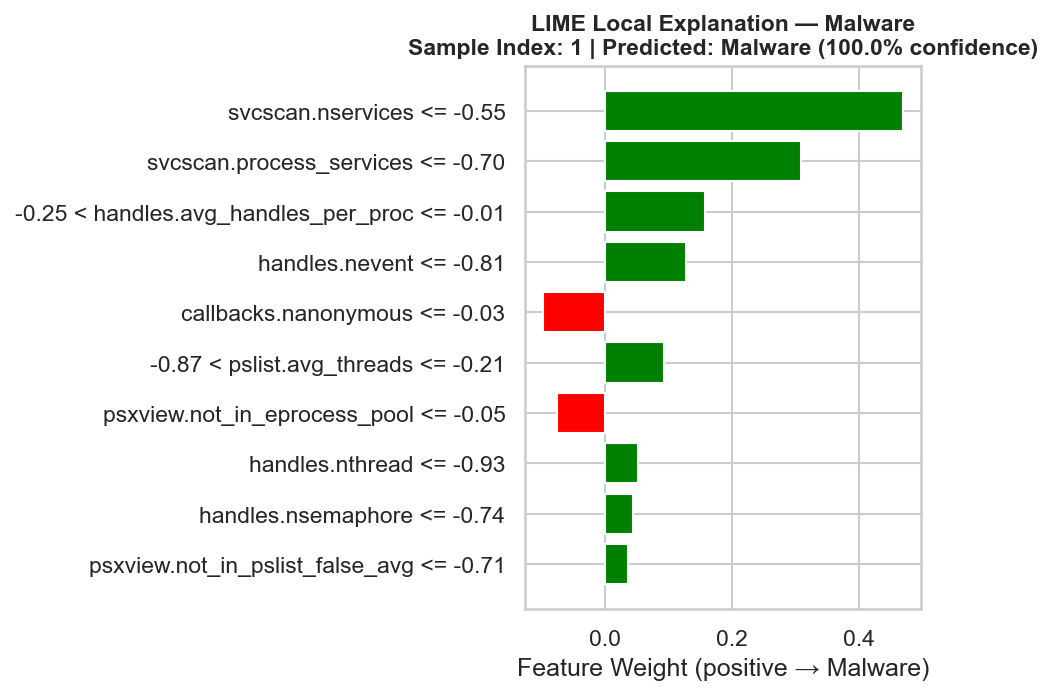


───────────────────────────────────────────────────────
 LIME FORENSIC REPORT — Malware
───────────────────────────────────────────────────────
  Instance    : Test Sample #1
  True Class  : Malware
  Prediction  : Malware
  Confidence  : 100.00%

  Top 10 Contributing Memory Artifacts:
  [↑ Malware Indicator]  svcscan.nservices <= -0.55: +0.4696
  [↑ Malware Indicator]  svcscan.process_services <= -0.70: +0.3097
  [↑ Malware Indicator]  -0.25 < handles.avg_handles_per_proc <= -0.01: +0.1585
  [↑ Malware Indicator]  handles.nevent <= -0.81: +0.1275
  [↓ Benign Indicator]  callbacks.nanonymous <= -0.03: -0.0967
  [↑ Malware Indicator]  -0.87 < pslist.avg_threads <= -0.21: +0.0930
  [↓ Benign Indicator]  psxview.not_in_eprocess_pool <= -0.05: -0.0747
  [↑ Malware Indicator]  handles.nthread <= -0.93: +0.0517
  [↑ Malware Indicator]  handles.nsemaphore <= -0.74: +0.0440
  [↑ Malware Indicator]  psxview.not_in_pslist_false_avg <= -0.71: +0.0365
────────────────────────────────────────────

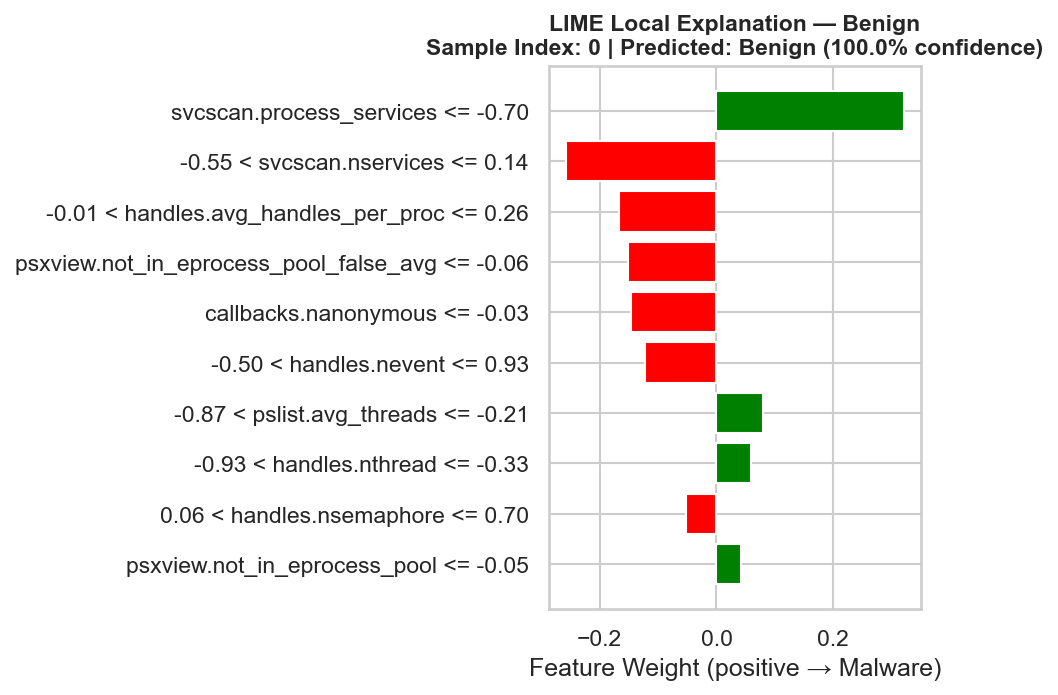


───────────────────────────────────────────────────────
 LIME FORENSIC REPORT — Benign
───────────────────────────────────────────────────────
  Instance    : Test Sample #0
  True Class  : Benign
  Prediction  : Benign
  Confidence  : 99.99%

  Top 10 Contributing Memory Artifacts:
  [↑ Malware Indicator]  svcscan.process_services <= -0.70: +0.3217
  [↓ Benign Indicator]  -0.55 < svcscan.nservices <= 0.14: -0.2587
  [↓ Benign Indicator]  -0.01 < handles.avg_handles_per_proc <= 0.26: -0.1667
  [↓ Benign Indicator]  psxview.not_in_eprocess_pool_false_avg <= -0.06: -0.1517
  [↓ Benign Indicator]  callbacks.nanonymous <= -0.03: -0.1459
  [↓ Benign Indicator]  -0.50 < handles.nevent <= 0.93: -0.1228
  [↑ Malware Indicator]  -0.87 < pslist.avg_threads <= -0.21: +0.0805
  [↑ Malware Indicator]  -0.93 < handles.nthread <= -0.33: +0.0591
  [↓ Benign Indicator]  0.06 < handles.nsemaphore <= 0.70: -0.0526
  [↑ Malware Indicator]  psxview.not_in_eprocess_pool <= -0.05: +0.0419
──────────────────

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 6B — LIME: LOCAL EXPLAINABILITY
#
# LIME (Local Interpretable Model-agnostic Explanations) explains ONE prediction
# by approximating the model locally with an interpretable surrogate.
# We explain: (1) a confirmed malware sample, (2) a confirmed benign sample.
# ─────────────────────────────────────────────────────────────────────────────

print("[*] Setting up LIME explainer...")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_cols,
    class_names=['Benign', 'Malware'],
    mode='classification',
    random_state=RANDOM_STATE
)

def explain_and_plot_lime(sample_index, label_name, output_prefix):
    """Generate and save a LIME explanation for a single test sample."""
    instance = X_test_scaled[sample_index]

    # Generate explanation
    exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=xgb_model.predict_proba,
        num_features=LIME_FEATURES
    )

    # Save as HTML (interactive)
    exp.save_to_file(f'{OUTPUT_DIR}{output_prefix}_lime.html')

    # Save as static figure
    fig = exp.as_pyplot_figure()
    plt.title(
        f"LIME Local Explanation — {label_name}\n"
        f"Sample Index: {sample_index} | Predicted: "
        f"{'Malware' if xgb_model.predict(instance.reshape(1,-1))[0]==1 else 'Benign'} "
        f"({np.max(xgb_model.predict_proba(instance.reshape(1,-1)))*100:.1f}% confidence)",
        fontsize=11, fontweight='bold'
    )
    plt.xlabel('Feature Weight (positive → Malware)')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}{output_prefix}_lime.png', bbox_inches='tight')
    plt.show()

    # Print forensic report
    print(f"\n{'─'*55}")
    print(f" LIME FORENSIC REPORT — {label_name}")
    print(f"{'─'*55}")
    pred_class  = 'Malware' if xgb_model.predict(instance.reshape(1,-1))[0] == 1 else 'Benign'
    confidence  = np.max(xgb_model.predict_proba(instance.reshape(1,-1))) * 100
    print(f"  Instance    : Test Sample #{sample_index}")
    print(f"  True Class  : {label_name}")
    print(f"  Prediction  : {pred_class}")
    print(f"  Confidence  : {confidence:.2f}%")
    print(f"\n  Top {LIME_FEATURES} Contributing Memory Artifacts:")
    for feat, weight in exp.as_list():
        direction = "↑ Malware Indicator" if weight > 0 else "↓ Benign Indicator"
        print(f"  [{direction}]  {feat}: {weight:+.4f}")
    print(f"{'─'*55}")

# Explain a confirmed malware sample
malware_indices = np.where(y_test == 1)[0]
benign_indices  = np.where(y_test == 0)[0]

explain_and_plot_lime(malware_indices[0], 'Malware', 'malware')
explain_and_plot_lime(benign_indices[0],  'Benign',  'benign')

print("\n[✓] LIME explanations saved (PNG + HTML).")

---
## Phase 7 — Model Comparison

[*] Running model comparison...
  → Training: XGBoost (Proposed)
  → Training: Random Forest
  → Training: Gradient Boosting
  → Training: MLP (Neural Net)
  → Training: Logistic Regression


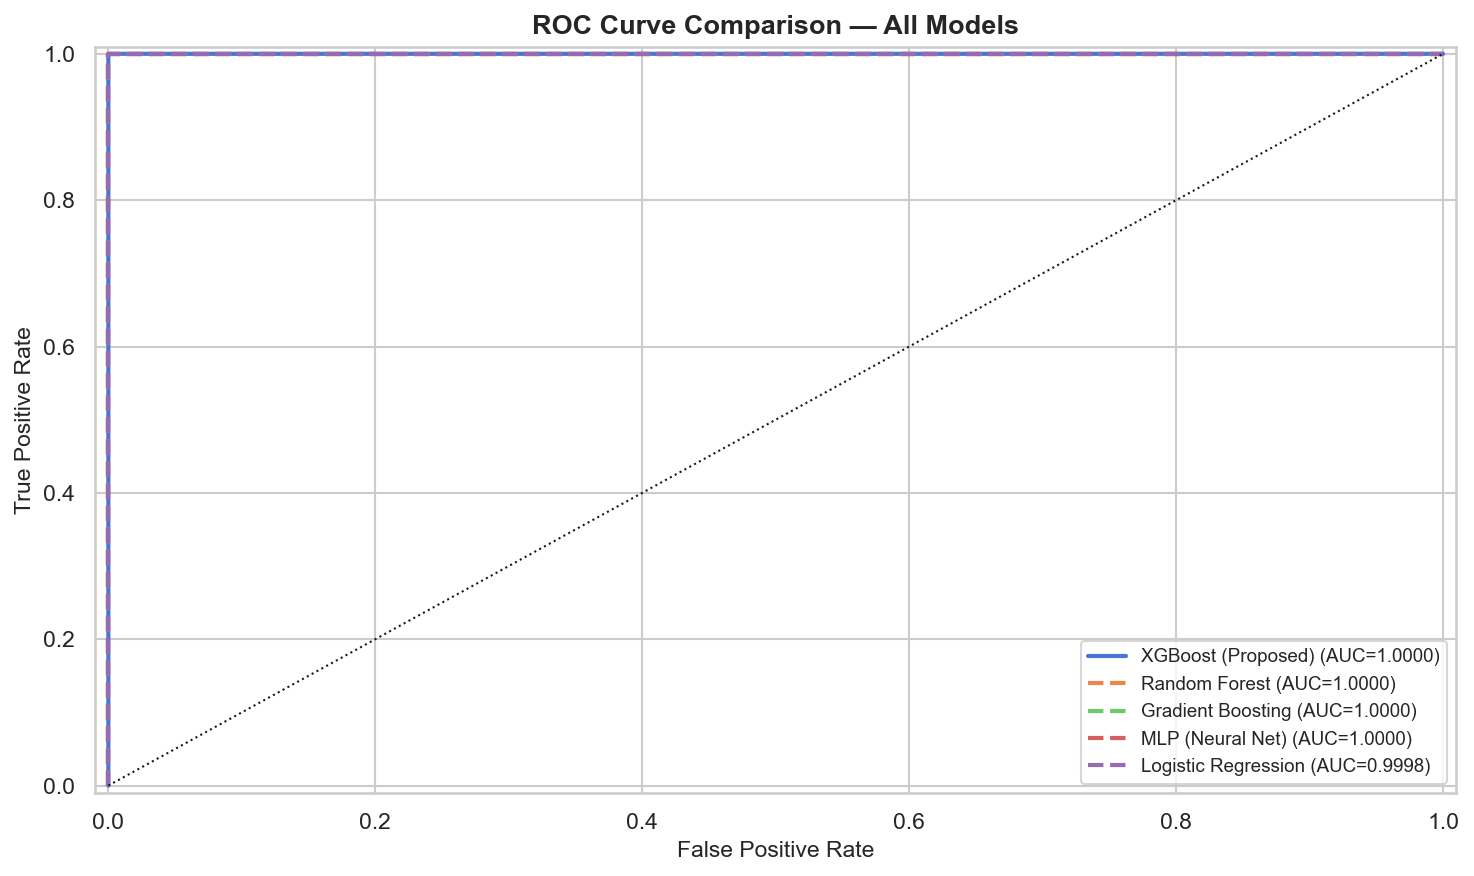


  MODEL COMPARISON — HOLD-OUT TEST SET
                 Model  Accuracy  F1-Score  ROC-AUC     MCC
1   XGBoost (Proposed)    1.0000    1.0000   1.0000  1.0000
2        Random Forest    1.0000    1.0000   1.0000  1.0000
3    Gradient Boosting    1.0000    1.0000   1.0000  1.0000
4     MLP (Neural Net)    1.0000    1.0000   1.0000  1.0000
5  Logistic Regression    0.9996    0.9996   0.9998  0.9991
[✓] Comparison table saved.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPARE XGBoost AGAINST BASELINE MODELS
#
# Models evaluated:
#   1. XGBoost           (proposed model)
#   2. Random Forest     (strong tree-based baseline)
#   3. Gradient Boosting (scikit-learn vanilla boosting)
#   4. MLP               (neural network baseline)
#   5. Logistic Regression (linear baseline)
# ─────────────────────────────────────────────────────────────────────────────

print("[*] Running model comparison...")

comparison_models = {
    'XGBoost (Proposed)'  : xgb_model,   # already trained
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                    random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                        learning_rate=0.05,
                                                        random_state=RANDOM_STATE),
    'MLP (Neural Net)'    : MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                                           random_state=RANDOM_STATE),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

results_list = []

fig, ax = plt.subplots(figsize=(10, 6))

for name, mdl in comparison_models.items():
    print(f"  → Training: {name}")

    # XGBoost is already trained; fit all others
    if name != 'XGBoost (Proposed)':
        mdl.fit(X_train_scaled, y_train)

    preds_m = mdl.predict(X_test_scaled)
    probs_m = mdl.predict_proba(X_test_scaled)[:, 1]

    fpr_m, tpr_m, _ = roc_curve(y_test, probs_m)
    auc_m   = auc(fpr_m, tpr_m)
    acc_m   = accuracy_score(y_test, preds_m)
    f1_m    = f1_score(y_test, preds_m)
    mcc_m   = matthews_corrcoef(y_test, preds_m)

    results_list.append({
        'Model'    : name,
        'Accuracy' : round(acc_m, 4),
        'F1-Score' : round(f1_m, 4),
        'ROC-AUC'  : round(auc_m, 4),
        'MCC'      : round(mcc_m, 4),
    })

    ls = '-' if name == 'XGBoost (Proposed)' else '--'
    ax.plot(fpr_m, tpr_m, lw=2, linestyle=ls,
            label=f'{name} (AUC={auc_m:.4f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve Comparison — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_comparison_roc.png', bbox_inches='tight')
plt.show()

# Print comparison table
results_df = pd.DataFrame(results_list).sort_values('ROC-AUC', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1

print("\n" + "=" * 65)
print("  MODEL COMPARISON — HOLD-OUT TEST SET")
print("=" * 65)
print(results_df.to_string())
print("=" * 65)

results_df.to_csv(f'{OUTPUT_DIR}model_comparison.csv', index=False)
print("[✓] Comparison table saved.")

---
## Phase 8 — Data Integrity & Leakage Audit

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# LEAKAGE AUDIT
#
# High accuracy (~99%) on CIC-MalMem-2022 is expected and documented in the
# literature (the dataset has very clean, separable features).
# However, we verify there is no artificial inflation from:
#   1. Train-test sample overlap
#   2. Target-correlated features (|r| > 0.95)
#   3. Permutation test (real signal vs chance)
# ─────────────────────────────────────────────────────────────────────────────

print("[*] Running Data Leakage & Integrity Audit...")

# ── Audit 1: Exact duplicate check between train and test
train_set = set(map(tuple, X_train.tolist()))
test_set  = set(map(tuple, X_test.tolist()))
overlap   = train_set.intersection(test_set)

print(f"\n[Audit 1 — Train/Test Overlap]")
print(f"  Overlapping exact samples: {len(overlap)}")
if len(overlap) == 0:
    print("  [✓] PASS — No data leakage via sample duplication.")
else:
    print(f"  [⚠️  FAIL] — {len(overlap)} samples appear in both train and test!")

# ── Audit 2: Near-perfect feature correlations (proxy leakage)
print(f"\n[Audit 2 — Feature-Target Correlation]")
leakage_suspects = correlations[correlations > 0.95].index.tolist()
if leakage_suspects:
    print(f"  [⚠️  WARNING] — {len(leakage_suspects)} features with |r| > 0.95:")
    for f in leakage_suspects:
        print(f"    → {f}")
    print("  Recommendation: These are highly predictive memory artifacts,")
    print("  not necessarily a flaw — but must be disclosed in the thesis.")
else:
    print("  [✓] PASS — No single feature with near-perfect correlation.")

# ── Audit 3: Permutation test
#   If our model performs similarly on permuted labels, the accuracy is meaningless.
print(f"\n[Audit 3 — Permutation Test (n=20 permutations)]")

perm_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, eval_metric='logloss',
    random_state=RANDOM_STATE
)

real_score, perm_scores, p_value = permutation_test_score(
    perm_model,
    X_train_scaled, y_train,
    cv=3, n_permutations=20,
    scoring='accuracy',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print(f"  Real model accuracy  : {real_score:.4f}")
print(f"  Permuted mean ± std  : {perm_scores.mean():.4f} ± {perm_scores.std():.4f}")
print(f"  p-value              : {p_value:.4f}")

if p_value < 0.05:
    print("  [✓] PASS — Real signal confirmed (p < 0.05). Model is not fitting noise.")
else:
    print("  [⚠️  WARNING] — p-value ≥ 0.05. Results may not be statistically significant.")

print("\n[✓] Leakage audit complete.")

[*] Running Data Leakage & Integrity Audit...

[Audit 1 — Train/Test Overlap]
  Overlapping exact samples: 10
  [⚠️  FAIL] — 10 samples appear in both train and test!

[Audit 2 — Feature-Target Correlation]
  [✓] PASS — No single feature with near-perfect correlation.

[Audit 3 — Permutation Test (n=20 permutations)]
  Real model accuracy  : 0.9998
  Permuted mean ± std  : 0.5004 ± 0.0028
  p-value              : 0.0476
  [✓] PASS — Real signal confirmed (p < 0.05). Model is not fitting noise.

[✓] Leakage audit complete.


[*] Noise Robustness Test...
  σ = 0.001 → Accuracy: 1.0000
  σ = 0.005 → Accuracy: 0.9999
  σ = 0.010 → Accuracy: 0.9999
  σ = 0.050 → Accuracy: 0.9997
  σ = 0.100 → Accuracy: 0.9991
  σ = 0.200 → Accuracy: 0.9920


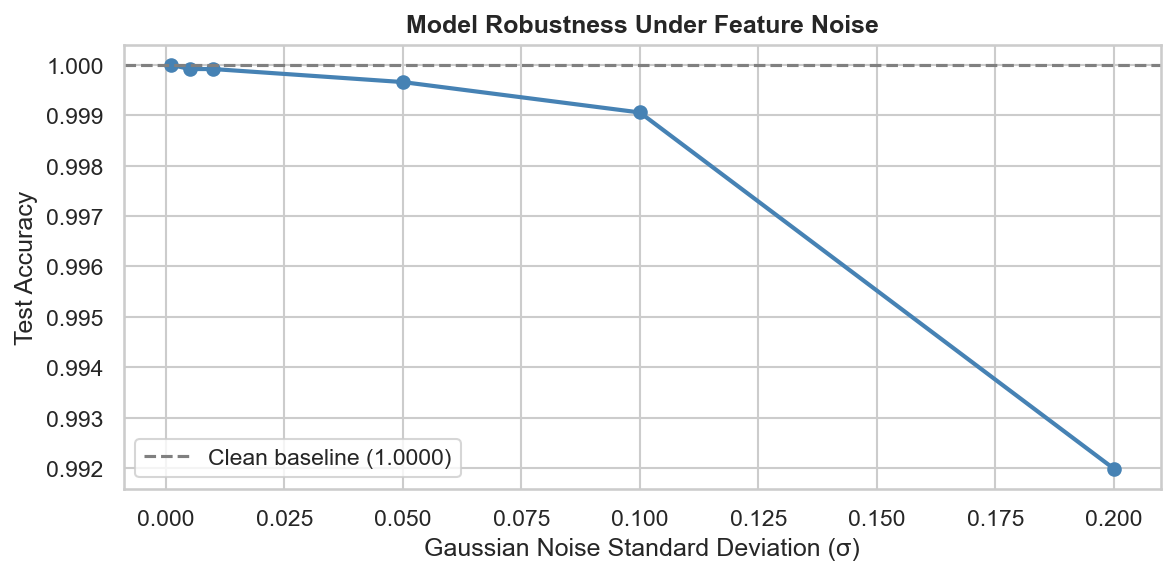

[✓] Noise robustness test complete.


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# NOISE ROBUSTNESS TEST
#
# A model that achieves 99.98% only when data is perfectly clean is fragile.
# We test how much accuracy drops when Gaussian noise is injected.
# A robust model should degrade gracefully.
# ─────────────────────────────────────────────────────────────────────────────

print("[*] Noise Robustness Test...")

noise_levels = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
noise_results = []

for sigma in noise_levels:
    rng = np.random.default_rng(RANDOM_STATE)
    X_noisy = X_test_scaled + rng.normal(0, sigma, X_test_scaled.shape)
    noisy_preds = xgb_model.predict(X_noisy)
    noisy_acc   = accuracy_score(y_test, noisy_preds)
    noise_results.append({'Noise σ': sigma, 'Accuracy': noisy_acc})
    print(f"  σ = {sigma:.3f} → Accuracy: {noisy_acc:.4f}")

noise_df = pd.DataFrame(noise_results)

plt.figure(figsize=(8, 4))
plt.plot(noise_df['Noise σ'], noise_df['Accuracy'], 'o-', color='steelblue', lw=2)
plt.axhline(y=test_acc, color='gray', linestyle='--', label=f'Clean baseline ({test_acc:.4f})')
plt.xlabel('Gaussian Noise Standard Deviation (σ)')
plt.ylabel('Test Accuracy')
plt.title('Model Robustness Under Feature Noise', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}noise_robustness.png', bbox_inches='tight')
plt.show()

print("[✓] Noise robustness test complete.")

---
## Phase 9 — Artifact Export

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE ALL ARTIFACTS
# ─────────────────────────────────────────────────────────────────────────────

print("[*] Saving all artifacts...")

# Model & Scaler
joblib.dump(xgb_model,    f'{OUTPUT_DIR}xgboost_malware_model.pkl')
joblib.dump(scaler,       f'{OUTPUT_DIR}standard_scaler.pkl')

# SHAP values (for later analysis)
np.save(f'{OUTPUT_DIR}shap_values.npy', shap_values.values)
pd.DataFrame(X_shap, columns=feature_cols).to_csv(f'{OUTPUT_DIR}shap_sample.csv', index=False)

# Final predictions on test set
test_export = pd.DataFrame({
    'True_Label'      : ['Malware' if l == 1 else 'Benign' for l in y_test],
    'Predicted_Label' : ['Malware' if p == 1 else 'Benign' for p in y_pred],
    'Malware_Prob'    : y_proba,
    'Correct'         : (y_test == y_pred)
})
test_export.to_csv(f'{OUTPUT_DIR}test_predictions.csv', index=False)

# Feature importance table
feat_importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
feat_importance_df.to_csv(f'{OUTPUT_DIR}feature_importance.csv', index=False)

# Summary metrics
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(f'{OUTPUT_DIR}metrics_summary.csv', index=False)

# ─────────────────────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("  PIPELINE COMPLETE — FINAL SUMMARY")
print("═" * 60)
print(f"  Dataset       : CIC-MalMem-2022")
print(f"  Total Samples : {len(df):,}  (train: {len(X_train):,} | test: {len(X_test):,})")
print(f"  Features Used : {len(feature_cols)}")
print()
for metric, value in metrics.items():
    print(f"  {metric:<25}: {value:.4f}")
print()
print(f"  XAI Methods   : SHAP (global) + LIME (local)")
print(f"  Models Compared: {len(comparison_models)}")
print(f"  Output Dir    : {os.path.abspath(OUTPUT_DIR)}")
print("═" * 60)

artifacts = [
    'xgboost_malware_model.pkl', 'standard_scaler.pkl',
    'shap_values.npy', 'shap_sample.csv',
    'test_predictions.csv', 'feature_importance.csv',
    'metrics_summary.csv', 'model_comparison.csv',
    'eda_dashboard.png', 'evaluation_dashboard.png',
    'shap_beeswarm.png', 'shap_bar.png',
    'malware_lime.png', 'malware_lime.html',
    'benign_lime.png',  'benign_lime.html',
    'model_comparison_roc.png', 'noise_robustness.png',
]

print("\n  Saved Artifacts:")
for artifact in artifacts:
    path = f'{OUTPUT_DIR}{artifact}'
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f"  [{status}] {artifact}")

[*] Saving all artifacts...

════════════════════════════════════════════════════════════
  PIPELINE COMPLETE — FINAL SUMMARY
════════════════════════════════════════════════════════════
  Dataset       : CIC-MalMem-2022
  Total Samples : 58,062  (train: 46,449 | test: 11,613)
  Features Used : 52

  Accuracy                 : 1.0000
  Precision                : 1.0000
  Recall (TPR)             : 1.0000
  F1-Score                 : 1.0000
  ROC-AUC                  : 1.0000
  Avg Precision (PR)       : 1.0000
  MCC                      : 1.0000

  XAI Methods   : SHAP (global) + LIME (local)
  Models Compared: 5
  Output Dir    : C:\Users\Ahmed El-khatib\Data Set\outputs
════════════════════════════════════════════════════════════

  Saved Artifacts:
  [✓] xgboost_malware_model.pkl
  [✓] standard_scaler.pkl
  [✓] shap_values.npy
  [✓] shap_sample.csv
  [✓] test_predictions.csv
  [✓] feature_importance.csv
  [✓] metrics_summary.csv
  [✓] model_comparison.csv
  [✓] eda_dashboard.png
  [